# 00 · Foundations — the words the cookbook assumes

The notebook that comes **before** everything else. It builds the core vocabulary — potential
outcomes, counterfactuals, confounding, randomization, identification, the do-operator, DAGs, ATE
vs CATE — from nothing, with one marketing example, and ends with a worked **estimator ladder**:
naive → regression-adjust → IPW → doubly-robust, each recovering a known effect from confounded
data.

No new theory here — it mirrors `docs/causal_inference_primer.pdf`. Skim it once and every later
notebook reads as a *named tool* rather than new vocabulary.


In [1]:
import os, numpy as np, pandas as pd
import matplotlib.pyplot as plt
import warnings; warnings.filterwarnings("ignore")
from cmp import dgp, estimators as est, plots
plots.use_style()
rng = np.random.default_rng(0)

## 1 · Treatment, unit, outcome — and the counterfactual

A **treatment** is any action whose effect we want (send a discount, show an ad, change a price).
The **unit** receives it (customer, store, region); the **outcome** is what we measure after.

For binary $T\in\{0,1\}$ each unit has **two potential outcomes**: $Y(1)$ if treated, $Y(0)$ if not.
We only observe **one** — $Y=T\,Y(1)+(1-T)\,Y(0)$ — so the individual effect $Y(1)-Y(0)$ is never
seen. This **fundamental problem of causal inference** is a *missing-data* problem; everything
downstream is principled imputation of the half of the table we didn't get to see.


In [2]:
# Three customers, both potential outcomes — we OBSERVE only the branch matching the treatment given.
demo = pd.DataFrame({"customer": ["Anna","Ben","Cara"],
    "Y(0) not emailed": [30, 55, 20], "Y(1) emailed": [80, 60, 22]})
demo["individual effect"] = demo["Y(1) emailed"] - demo["Y(0) not emailed"]
demo["emailed?"] = ["yes","no","yes"]
demo["→ OBSERVED"] = [80, 55, 22]; demo["→ MISSING (counterfactual)"] = [30, 60, 20]
demo

,customer,Y(0) not emailed,Y(1) emailed,individual effect,emailed?,→ OBSERVED,→ MISSING (counterfactual)
0,Anna,30,80,50,yes,80,30
1,Ben,55,60,5,no,55,60
2,Cara,20,22,2,yes,22,20


## 2 · From individuals to averages, and the enemy: confounding

Decisions run on **averages**: the **Average Treatment Effect** $\text{ATE}=\mathbb E[Y(1)-Y(0)]$.
The whole difficulty collapses onto one word — **comparable**: to estimate $\mathbb E[Y(0)]$ for the
treated we need a control group *like them in every way except the treatment*.

**Confounding** breaks comparability. If we email our *loyal* customers and compare to *casual*
controls, loyal customers spend more anyway — "loyalty" drove both who got emailed and how much they
spend. A **confounder** is a common cause of treatment and outcome; the naive "treated − control"
difference then blames the treatment for a gap that was really about *who ended up in each group*.


## 3 · The gold standard, and life without it

**Randomization** (an A/B test) annihilates confounding by design: a coin flip makes treatment
independent of every confounder, measured or not, so $\text{ATE}=\langle Y\mid T{=}1\rangle-\langle
Y\mid T{=}0\rangle$ — a plain difference of means. We can *see* this: the same simulator run in
**randomized** vs **observational** mode gives the same true effect, but only the randomized naive
estimate is unbiased.


true ATE €5.6  ·  randomized naive €4.8 (unbiased)  ·  observational naive €11.4 (confounded)


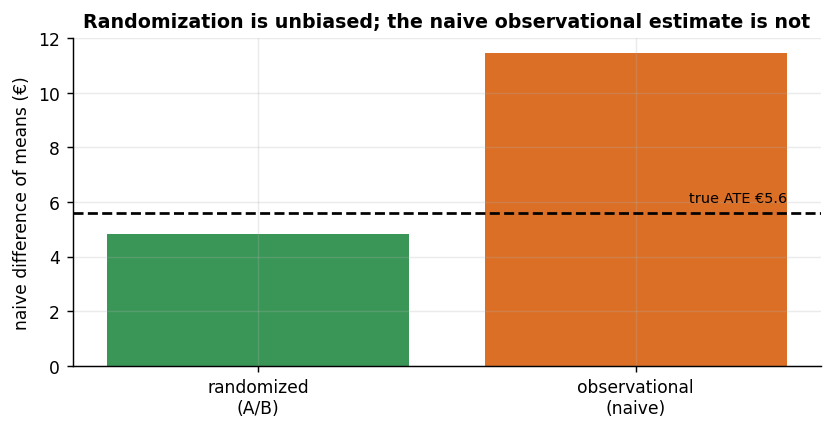

In [3]:
COST = 8.0
rand = dgp.uplift_customers(n=3000, regime="randomized", seed=1)
obs  = dgp.uplift_customers(n=3000, regime="observational", seed=1)
def naive(d): return d.loc[d["T"]==1,"y"].mean() - d.loc[d["T"]==0,"y"].mean()
fig, ax = plt.subplots(figsize=(6.5, 3.4))
ax.bar(["randomized\n(A/B)","observational\n(naive)"], [naive(rand), naive(obs)], color=[plots.GREEN, plots.ORANGE], alpha=0.9)
ax.axhline(rand.tau.mean(), color="k", ls="--"); ax.text(1.4, rand.tau.mean()+0.4, f"true ATE €{rand.tau.mean():.1f}", ha="right", fontsize=8)
ax.set_ylabel("naive difference of means (€)"); ax.set_title("Randomization is unbiased; the naive observational estimate is not")
fig.tight_layout()
print(f"true ATE €{rand.tau.mean():.1f}  ·  randomized naive €{naive(rand):.1f} (unbiased)  ·  observational naive €{naive(obs):.1f} (confounded)")

Without randomization we must **identify** the effect using assumptions:

1. **Unconfoundedness** $\{Y(0),Y(1)\}\perp T\mid X$ — within units alike on measured $X$, treatment
   is as-good-as-random. *(The big, untestable one.)*
2. **Positivity / overlap** $0<e(x)<1$, $e(x)=P(T{=}1\mid X{=}x)$ the **propensity score** — every
   kind of unit could have gone either way.
3. **SUTVA** — no interference, one version of treatment.

Under these, the **adjustment (g-)formula** compares like-with-like *within* strata of $X$ and averages
back up:
$\text{ATE}=\mathbb E_X[\mathbb E[Y\mid T{=}1,X]-\mathbb E[Y\mid T{=}0,X]]$.


## 4 · Seeing vs doing (the do-operator), DAGs, colliders

**Observing** $X=x$ (units where $X$ happened to be $x$, carrying all the reasons it got there) differs
from **doing** $do(X=x)$ (reaching in and *setting* it). Causal effects are about *doing*. A **DAG**
draws each variable as a node and each direct cause as an arrow, and tells you exactly what to control
for:


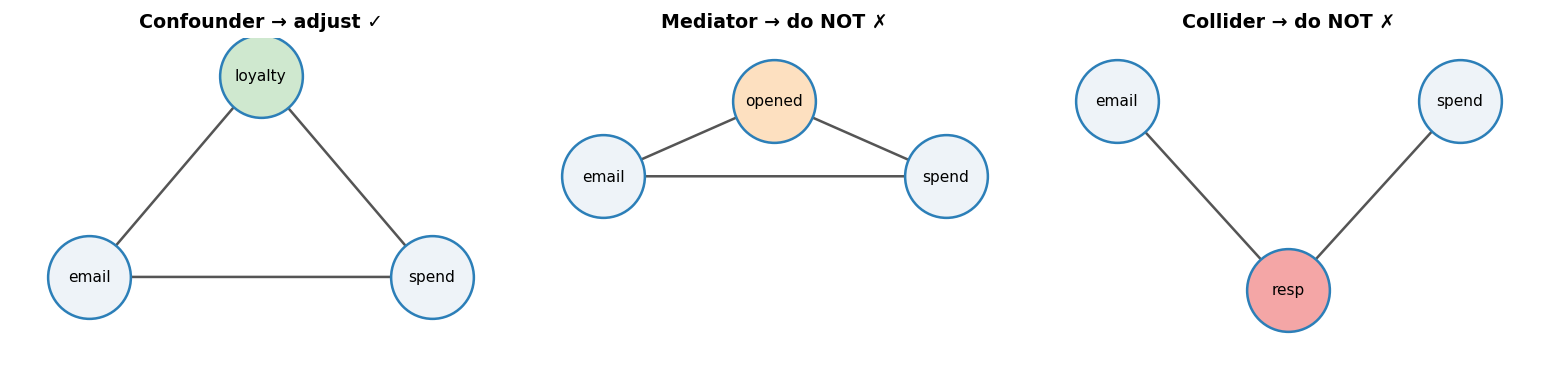

In [4]:
fig, ax = plt.subplots(1, 3, figsize=(12, 3.0))
plots.draw_dag(ax[0], {"loyalty":(0.5,1.0),"email":(0.05,0.2),"spend":(0.95,0.2)},
    [("loyalty","email"),("loyalty","spend"),("email","spend")], node_colors={"loyalty":"#cfe8cf"}, title="Confounder → adjust ✓")
plots.draw_dag(ax[1], {"email":(0.05,0.6),"opened":(0.5,0.9),"spend":(0.95,0.6)},
    [("email","opened"),("opened","spend"),("email","spend")], node_colors={"opened":"#fde0c0"}, title="Mediator → do NOT ✗")
plots.draw_dag(ax[2], {"email":(0.05,0.9),"spend":(0.95,0.9),"resp":(0.5,0.15)},
    [("email","resp"),("spend","resp")], node_colors={"resp":"#f4a6a6"}, title="Collider → do NOT ✗")
fig.tight_layout()

- **Backdoor path** (arrow *into* T, e.g. $T\leftarrow$ loyalty $\rightarrow Y$): block it by
  conditioning — the minimal blocking set is the $X$ in the adjustment formula.
- **Mediator** ($T\to M\to Y$): controlling for $M$ removes part of the effect you want.
- **Collider** ($T\to C\leftarrow Y$): conditioning on $C$ *manufactures* a spurious association.
  Notebook 05 is the whole "what to control for" story.


## 5 · One effect for everyone, or a different effect for each?

- **ATE** — one number ("did the program lift revenue overall?"): **program evaluation /
  incrementality** (notebooks 06–11).
- **CATE** $\tau(x)=\mathbb E[Y(1)-Y(0)\mid X{=}x]$ — the effect as a function of *who*:
  **heterogeneous treatment effects** (notebooks 01–04). If $\tau$ were identical for everyone, there'd
  be no one to select — targeting works *because* $\tau(x)$ varies.

*(Sometimes a method only recovers the effect for a sub-population — e.g. the compliers an instrument
nudges. That restricted quantity is a **LATE**; notebook 11.)*


## 6 · The estimator ladder — four ways to recover one effect

Where the machinery enters. On the **confounded** data (true effect €6), we climb a ladder of
estimators, each leaning on different assumptions, and watch them converge on the truth as we do the
adjustment right:

1. **Naive** difference of means — ignores $X$, biased up.
2. **Regression adjustment** — model $\mathbb E[Y\mid T,X]$, average the contrast (right if the outcome
   model is right).
3. **IPW** — reweight by the inverse propensity so treated/control look alike (right if the propensity
   model is right).
4. **AIPW (doubly-robust)** — combine both; consistent if *either* model is right, with a credible
   interval.


1. naive         € 9.26   (true €6.0)
2. regression    € 5.60   (true €6.0)
3. IPW           € 5.80   (true €6.0)
4. AIPW (DR)     € 5.59   (true €6.0)


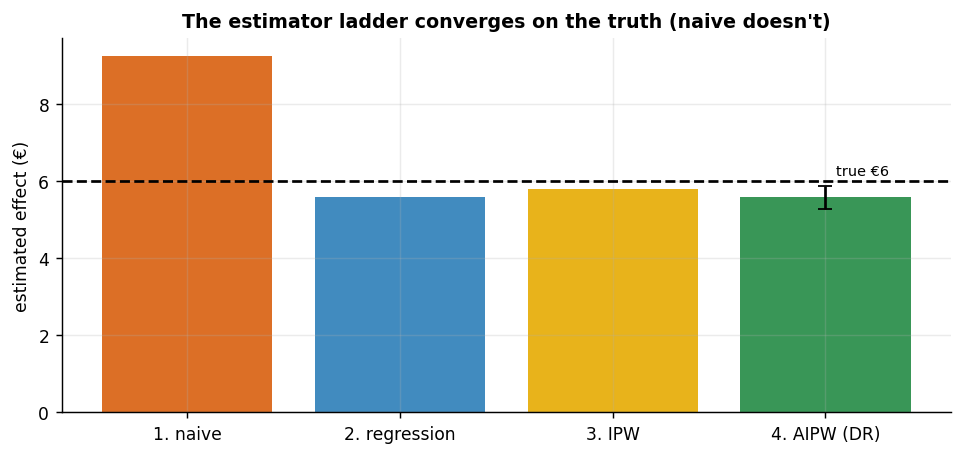

In [5]:
d, true_ate = dgp.dag_control_demo(n=3000, seed=17)
X = d[["loyalty"]].values; T = d["email"].values; Y = d["spend"].values

# 1. naive
naive_est = Y[T==1].mean() - Y[T==0].mean()
# 2. regression adjustment (g-formula with linear outcome model)
D = np.column_stack([np.ones(len(d)), T, d["loyalty"].values]); beta = np.linalg.lstsq(D, Y, rcond=None)[0]
reg_est = beta[1]
# 3. IPW
e = est.propensity_scores(X, T); e = np.clip(e, 0.05, 0.95)
ipw_est = (T*Y/e).mean() - ((1-T)*Y/(1-e)).mean()
# 4. AIPW doubly-robust
aipw = est.aipw_ate(X, T, Y, seed=1, n_boot=300)

ladder = {"1. naive": naive_est, "2. regression": reg_est, "3. IPW": ipw_est, "4. AIPW (DR)": aipw["ate"]}
fig, ax = plt.subplots(figsize=(7.5, 3.6))
cols = [plots.ORANGE, plots.BLUE, plots.GOLD, plots.GREEN]
ax.bar(list(ladder.keys()), list(ladder.values()), color=cols, alpha=0.9)
ax.axhline(true_ate, color="k", ls="--"); ax.text(3.3, true_ate+0.15, f"true €{true_ate:.0f}", ha="right", fontsize=8)
ax.errorbar(3, aipw["ate"], yerr=[[aipw["ate"]-aipw["ci90"][0]],[aipw["ci90"][1]-aipw["ate"]]], color="k", capsize=4)
ax.set_ylabel("estimated effect (€)"); ax.set_title("The estimator ladder converges on the truth (naive doesn't)")
fig.tight_layout()
for k,v in ladder.items(): print(f"{k:16s} €{v:5.2f}   (true €{true_ate:.1f})")

> The discipline: **Bayes/ML sharpens estimation, never identification.** A tight, beautiful posterior
> computed under a false unconfoundedness assumption is *confidently wrong*. Priors don't fix broken
> causal arguments — the graph does. Every notebook keeps identification (this ladder's assumptions)
> separate from estimation (which rung you climb).


## 6b · The same lesson on **real, famous data** (LaLonde 1986)

The ladder above ran on our simulator. Here is the identical confounding story on the most famous real
dataset in causal inference — **you don't provide anything; it's fetched from a public URL**:

> **LaLonde / NSW** — a 1970s job-training program. Because it included a **randomized** arm, we know the
> *true* effect of training on 1978 earnings: about **+\$1,800**. But if we throw away the randomized
> controls and instead compare the trained workers to a *non-experimental* comparison group (people
> pulled from national surveys), a naive difference is **badly negative** — it looks like training
> *hurt* earnings, because the trained group was far more disadvantaged to begin with (the confounding).
> Adjusting for the measured covariates pulls the estimate back toward the true +\$1,800. This single
> dataset is why the field takes confounding seriously.

Gated on `CMP_REAL=1` (keeps the offline test suite deterministic).


In [6]:
if os.environ.get("CMP_REAL") == "1":
    from cmp import data
    ll = data.load_lalonde()
    covs = ["age", "educ", "black", "hispan", "married", "nodegree", "re74", "re75"]
    T2, Y2 = ll["treat"].values, ll["re78"].values
    naive2 = Y2[T2==1].mean() - Y2[T2==0].mean()
    D2 = np.column_stack([np.ones(len(ll)), T2, ll[covs].values])
    adj2 = np.linalg.lstsq(D2, Y2, rcond=None)[0][1]
    print(f"LaLonde (observational comparison group), effect of training on 1978 earnings:")
    print(f"  naive difference of means : ${naive2:,.0f}   (biased — trained group started far poorer)")
    print(f"  covariate-adjusted        : ${adj2:,.0f}   (moves toward the ~$1,800 experimental truth)")
else:
    print("Real-data section skipped. Set CMP_REAL=1 and re-run to fetch the LaLonde dataset.")

Real-data section skipped. Set CMP_REAL=1 and re-run to fetch the LaLonde dataset.


### The eight words to walk in with

**Treatment** · **counterfactual / potential outcome** (the branch you didn't observe) · **confounder**
(common cause of treatment and outcome) · **randomization** (kills confounding by design) ·
**identification** (the assumptions that make an effect recoverable) · **do-operator** (forcing vs
observing) · **backdoor / collider** (what to control for, and what never to) · **ATE vs CATE** (one
effect for all vs a different effect per customer).

**Next:** [01 · uplift targeting](01_uplift_targeting.ipynb) (Anchor A, HTE) and
[07 · geo-lift synthetic control](07_geo_lift_synthetic_control.ipynb) (Anchor B, program evaluation) —
then the rest of the cookbook.
